<a href="https://colab.research.google.com/github/subudear/deep-learning/blob/main/assignment1/scratch_class_weight_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# STEP 1: Imports and GPU check**

In [1]:

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GPU available: True
GPU name: Tesla T4
Using device: cuda


**# STEP 2: Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


**# STEP 3: Extract dataset zip files**

In [3]:
dataset_path = "/content/drive/MyDrive/compx525assign1/cell_cultures"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

for f in os.listdir(dataset_path):
    if f.endswith(".zip"):
        zip_path = os.path.join(dataset_path, f)
        print("Extracting:", zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction complete")
print("Extracted folders:", os.listdir(extract_path))



Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/test.zip
Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/train.zip
Extraction complete
Extracted folders: ['train', 'test']


**# STEP 4: DEFINE TRAIN AND TEST PATHS**

In [4]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"
image_exts = (".jpg", ".jpeg", ".png")

classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Folder classes:", classes)
print("Number of folder classes:", len(classes))

print("Usable image counts per class:")
for c in classes:
    cls_path = os.path.join(train_dir, c)
    count = sum(fname.lower().endswith(image_exts) for fname in os.listdir(cls_path))
    print(c, count)

print("Test images:", len([f for f in os.listdir(test_dir) if f.lower().endswith(image_exts)]))


Folder classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of folder classes: 17
Usable image counts per class:
a 1283
b 4
c 475
d 266
e 117
f 59
g 720
h 5
i 199
j 0
k 12
l 660
m 543
n 91
o 197
p 35
q 29
Test images: 512


**# STEP 5: Set train/test paths and count usable images**

In [5]:
rows = []

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(image_exts):
                rows.append({
                    "filepath": os.path.join(cls_path, fname),
                    "label": cls
                })

train_df = pd.DataFrame(rows)

print(train_df.head())
print("\nTotal usable training images:", len(train_df))
print("\nUsable class counts:")
print(train_df["label"].value_counts().sort_index())

                                   filepath label
0   /content/dataset/train/a/z218573767.jpg     a
1  /content/dataset/train/a/z1813342289.jpg     a
2   /content/dataset/train/a/z868447228.jpg     a
3     /content/dataset/train/a/z2971842.jpg     a
4   /content/dataset/train/a/z670494583.jpg     a

Total usable training images: 4695

Usable class counts:
label
a    1283
b       4
c     475
d     266
e     117
f      59
g     720
h       5
i     199
k      12
l     660
m     543
n      91
o     197
p      35
q      29
Name: count, dtype: int64


**# STEP 6: TRAIN / VALIDATION SPLIT**

In [6]:
class_counts = train_df["label"].value_counts()

# Keep singleton classes in training only
singleton_classes = class_counts[class_counts < 2].index.tolist()
singleton_df = train_df[train_df["label"].isin(singleton_classes)].copy()
normal_df = train_df[~train_df["label"].isin(singleton_classes)].copy()

train_split_df, val_split_df = train_test_split(
    normal_df,
    test_size=0.2,
    stratify=normal_df["label"],
    random_state=42
)

train_split_df = pd.concat([train_split_df, singleton_df], ignore_index=True)

print("Train size:", len(train_split_df))
print("Val size:", len(val_split_df))
print("\nTrain split class counts:")
print(train_split_df["label"].value_counts().sort_index())
print("\nVal split class counts:")
print(val_split_df["label"].value_counts().sort_index())

Train size: 3756
Val size: 939

Train split class counts:
label
a    1026
b       3
c     380
d     213
e      94
f      47
g     576
h       4
i     159
k      10
l     528
m     434
n      73
o     158
p      28
q      23
Name: count, dtype: int64

Val split class counts:
label
a    257
b      1
c     95
d     53
e     23
f     12
g    144
h      1
i     40
k      2
l    132
m    109
n     18
o     39
p      7
q      6
Name: count, dtype: int64


**# STEP 7: ENCODE LABELS**

In [7]:
label_to_idx = {
    label: idx for idx, label in enumerate(sorted(train_df["label"].unique()))
}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

effective_classes = sorted(label_to_idx.keys())
print("Usable classes:", effective_classes)
print("Number of usable classes:", len(effective_classes))
print("label_to_idx:", label_to_idx)

train_split_df["label_idx"] = train_split_df["label"].map(label_to_idx)
val_split_df["label_idx"] = val_split_df["label"].map(label_to_idx)

print(train_split_df.head())
print(val_split_df.head())

Usable classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of usable classes: 16
label_to_idx: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'q': 15}
                                   filepath label  label_idx
0  /content/dataset/train/l/z1728134539.jpg     l         10
1   /content/dataset/train/a/z461066921.jpg     a          0
2   /content/dataset/train/i/z850361057.jpg     i          8
3   /content/dataset/train/a/z275939099.jpg     a          0
4   /content/dataset/train/a/z365386909.jpg     a          0
                                      filepath label  label_idx
2879   /content/dataset/train/g/z601380699.jpg     g          6
3435  /content/dataset/train/l/z1765107073.jpg     l         10
2157  /content/dataset/train/f/z1998937689.jpg     f          5
2346   /content/dataset/train/g/z940782865.jpg     g          6
2367    /content/dataset/train/g/z80764

**# STEP B1: CLASS WEIGHTS FOR EXPERIMENT B**

In [8]:
all_class_indices = list(range(len(label_to_idx)))

class_counts = (
    train_split_df["label_idx"]
    .value_counts()
    .reindex(all_class_indices, fill_value=0)
    .sort_index()
)

print("Class counts:")
print(class_counts)

safe_counts = class_counts.replace(0, 1)
counts_tensor = torch.tensor(safe_counts.values, dtype=torch.float)

class_weights = 1.0 / counts_tensor
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = class_weights.to(device)

print("Class weights:", class_weights)

Class counts:
label_idx
0     1026
1        3
2      380
3      213
4       94
5       47
6      576
7        4
8      159
9       10
10     528
11     434
12      73
13     158
14      28
15      23
Name: count, dtype: int64
Class weights: tensor([0.0187, 6.3873, 0.0504, 0.0900, 0.2038, 0.4077, 0.0333, 4.7905, 0.1205,
        1.9162, 0.0363, 0.0442, 0.2625, 0.1213, 0.6844, 0.8331],
       device='cuda:0')


**# STEP 8: ScratchCNN transforms**

In [9]:
scratch_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

scratch_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**# STEP 9: ScratchCNN datasets and loaders**

In [10]:
class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        label = self.df.loc[idx, "label_idx"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


scratch_train_dataset = ImageDataset(train_split_df, transform=scratch_train_transform)
scratch_val_dataset = ImageDataset(val_split_df, transform=scratch_val_transform)

scratch_train_loader = DataLoader(scratch_train_dataset, batch_size=32, shuffle=True)
scratch_val_loader = DataLoader(scratch_val_dataset, batch_size=32, shuffle=False)

print("Scratch train dataset size:", len(scratch_train_dataset))
print("Scratch val dataset size:", len(scratch_val_dataset))

Scratch train dataset size: 3756
Scratch val dataset size: 939


**# STEP 10: define and create ScratchCNN class**

In [11]:
class ScratchCNN(nn.Module):
    def __init__(self,num_classes):
        super(ScratchCNN, self).__init__()

        #feature extractor part
        self.features = nn.Sequential(
            #Block 1
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            #Block 2
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            #Block 3
            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),

            #Block 4
            nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        #Classifier part

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*14*14,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )

    def forward(self, x):
        # Pass input through feature extractor
        x = self.features(x)

        # Pass extracted features into classifier
        x = self.classifier(x)

        return x


scratch_model = ScratchCNN(num_classes=len(label_to_idx))
scratch_model = scratch_model.to(device)

print(scratch_model)
print("Device:", device)


ScratchCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=16, bias=True)
  )


**# STEP 11: define scratch_criterion and scratch_optimizer**

In [12]:
# CrossEntropyLoss is the standard loss function for multi-class classification.
# Our model outputs one score (logit) per class.
# The true label is a single class index such as 0, 1, 2, ..., 15.
# This loss compares:
#   - what the model predicted
#   - what the correct class actually is
# and returns a single number showing how wrong the prediction is.
#
# Lower loss = better predictions
# Higher loss = worse predictions
#
# We use this because:
#   - this is a multi-class classification task
#   - only one class is correct for each image
scratch_criterion =  nn.CrossEntropyLoss(weight=class_weights)

# Adam is the optimizer that updates the model's weights during training.
# After loss is computed, backpropagation calculates gradients.
# The optimizer uses those gradients to change the weights slightly
# so the model can improve on the next batch.
#
# scratch_model.parameters() means:
#   - update ALL learnable parameters in the ScratchCNN
#   - unlike transfer learning, we are not freezing any layers here
#   - every layer starts from random weights and must be learned from scratch
#
# lr=1e-3 means learning rate = 0.001
# The learning rate controls how big each update step is.
# If it is too large:
#   - training may become unstable
# If it is too small:
#   - training may become very slow
#
# 1e-3 is a common starting value for Adam.
scratch_optimizer = optim.Adam(
    scratch_model.parameters(),
    lr=1e-3
)

# Print both objects so we can confirm they were created correctly.
print("Scratch model loss function:")
print(scratch_criterion)

print("\nScratch model optimizer:")
print(scratch_optimizer)

Scratch model loss function:
CrossEntropyLoss()

Scratch model optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


**# STEP 12: train ScratchCNN using scratch_train_loader and scratch_val_loader**

In [13]:
# Path where the best ScratchCNN model will be saved
scratch_best_path = "/content/drive/MyDrive/scratchcnn_B_weightedloss_best.pth"

# Keep track of the best validation accuracy seen so far
best_scratch_val_acc = 0.0

# Number of training epochs for the first ScratchCNN experiment
num_epochs = 10

for epoch in range(num_epochs):
    # -------------------------
    # TRAINING PHASE
    # -------------------------

    # Put the model into training mode
    # This matters because layers like Dropout behave differently in training
    scratch_model.train()

    # Running total of loss over all training batches in this epoch
    running_loss = 0.0

    # Counters for training accuracy
    train_correct = 0
    train_total = 0

    # Loop through batches from the SCRATCH training loader
    for batch_idx, (images, labels) in enumerate(scratch_train_loader):
        # Move images and labels to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients from the previous batch
        scratch_optimizer.zero_grad()

        # Forward pass:
        # send images through ScratchCNN to get class scores
        outputs = scratch_model(images)

        # Compute loss between predicted scores and true labels
        loss = scratch_criterion(outputs, labels)

        # Backward pass:
        # compute gradients for all learnable weights
        loss.backward()

        # Optimizer step:
        # update model weights using those gradients
        scratch_optimizer.step()

        # Add batch loss to the running loss total
        running_loss += loss.item()

        # Get predicted class index for each image
        _, preds = torch.max(outputs, 1)

        # Count correct predictions in this batch
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        # Print progress every 20 batches so you know training is moving
        if (batch_idx + 1) % 20 == 0:
            print(f"ScratchCNN | Epoch {epoch+1}/{num_epochs} | Batch {batch_idx+1}/{len(scratch_train_loader)}")

    # Compute average training loss for this epoch
    train_loss = running_loss / len(scratch_train_loader)

    # Compute training accuracy for this epoch
    train_acc = train_correct / train_total

    # -------------------------
    # VALIDATION PHASE
    # -------------------------

    # Put model into evaluation mode
    # This turns off training-specific randomness such as Dropout
    scratch_model.eval()

    # Counters for validation accuracy
    val_correct = 0
    val_total = 0

    # Turn off gradients during validation to save memory and speed things up
    with torch.no_grad():
        # Loop through batches from the SCRATCH validation loader
        for images, labels in scratch_val_loader:
            # Move validation data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass only
            outputs = scratch_model(images)

            # Get predicted class index
            _, preds = torch.max(outputs, 1)

            # Update validation counters
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Compute validation accuracy
    val_acc = val_correct / val_total

    # Save model only if this epoch is the best so far
    if val_acc > best_scratch_val_acc:
        best_scratch_val_acc = val_acc

        torch.save(
            {
                "model_state_dict": scratch_model.state_dict(),
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label,
                "best_val_acc": best_scratch_val_acc
            },
            scratch_best_path
        )

        print(f"Saved new best ScratchCNN model at epoch {epoch+1}")

    # Print summary for the epoch
    print(
        f"ScratchCNN | Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
    )

# Final summary after all epochs
print("\nBest ScratchCNN validation accuracy:", best_scratch_val_acc)
print("Best ScratchCNN model saved to:", scratch_best_path)

ScratchCNN | Epoch 1/10 | Batch 20/118
ScratchCNN | Epoch 1/10 | Batch 40/118
ScratchCNN | Epoch 1/10 | Batch 60/118
ScratchCNN | Epoch 1/10 | Batch 80/118
ScratchCNN | Epoch 1/10 | Batch 100/118
Saved new best ScratchCNN model at epoch 1
ScratchCNN | Epoch 1/10 | Train Loss: 2.7748 | Train Acc: 0.1118 | Val Acc: 0.1076
ScratchCNN | Epoch 2/10 | Batch 20/118
ScratchCNN | Epoch 2/10 | Batch 40/118
ScratchCNN | Epoch 2/10 | Batch 60/118
ScratchCNN | Epoch 2/10 | Batch 80/118
ScratchCNN | Epoch 2/10 | Batch 100/118
Saved new best ScratchCNN model at epoch 2
ScratchCNN | Epoch 2/10 | Train Loss: 2.7807 | Train Acc: 0.0972 | Val Acc: 0.1512
ScratchCNN | Epoch 3/10 | Batch 20/118
ScratchCNN | Epoch 3/10 | Batch 40/118
ScratchCNN | Epoch 3/10 | Batch 60/118
ScratchCNN | Epoch 3/10 | Batch 80/118
ScratchCNN | Epoch 3/10 | Batch 100/118
ScratchCNN | Epoch 3/10 | Train Loss: 2.7479 | Train Acc: 0.0961 | Val Acc: 0.0245
ScratchCNN | Epoch 4/10 | Batch 20/118
ScratchCNN | Epoch 4/10 | Batch 40/118

**#STEP 13: EVALUATE BEST ScratchCNN ON VALIDATION SET**

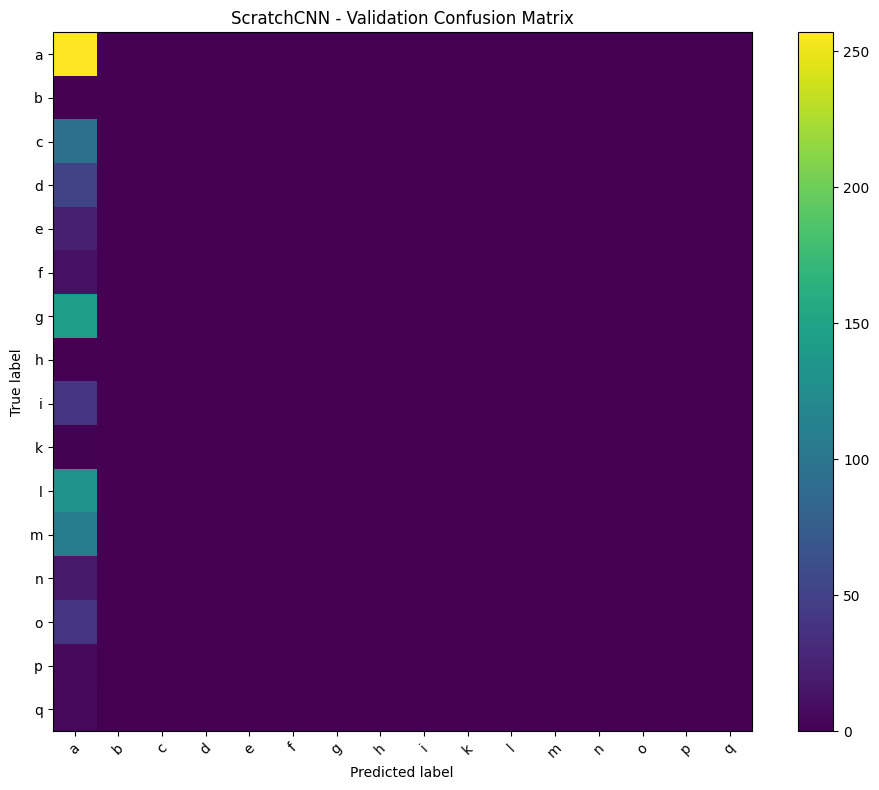

              precision    recall  f1-score   support

           a       0.27      1.00      0.43       257
           b       0.00      0.00      0.00         1
           c       0.00      0.00      0.00        95
           d       0.00      0.00      0.00        53
           e       0.00      0.00      0.00        23
           f       0.00      0.00      0.00        12
           g       0.00      0.00      0.00       144
           h       0.00      0.00      0.00         1
           i       0.00      0.00      0.00        40
           k       0.00      0.00      0.00         2
           l       0.00      0.00      0.00       132
           m       0.00      0.00      0.00       109
           n       0.00      0.00      0.00        18
           o       0.00      0.00      0.00        39
           p       0.00      0.00      0.00         7
           q       0.00      0.00      0.00         6

    accuracy                           0.27       939
   macro avg       0.02   

In [14]:
# Rebuild the ScratchCNN model structure
scratch_model = ScratchCNN(num_classes=len(label_to_idx))
scratch_model = scratch_model.to(device)

# Load the best saved ScratchCNN model
checkpoint_path = "/content/drive/MyDrive/scratchcnn_B_weightedloss_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
scratch_model.load_state_dict(checkpoint["model_state_dict"])

# Put model in evaluation mode
scratch_model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in scratch_val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = scratch_model(images)
        _, preds = torch.max(outputs, 1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

# Build confusion matrix
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("ScratchCNN - Validation Confusion Matrix")
plt.colorbar()

class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# Print classification report
print(classification_report(
    all_true,
    all_pred,
    target_names=class_names,
    zero_division=0
))

**# STEP 15: CREATE TEST DATAFRAME AND TEST DATALOADER**



In [15]:
test_rows = []

for fname in sorted(os.listdir(test_dir)):
    if fname.lower().endswith(image_exts):
        test_rows.append({
            "filepath": os.path.join(test_dir, fname),
            "filename": fname
        })

test_df = pd.DataFrame(test_rows)
print(test_df.head())
print("Total test images:", len(test_df))


class TestImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        filename = self.df.loc[idx, "filename"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename


test_dataset = TestImageDataset(test_df, transform=scratch_val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test dataset size:", len(test_dataset))

                                filepath         filename
0    /content/dataset/test/z10002793.jpg    z10002793.jpg
1  /content/dataset/test/z1002467769.jpg  z1002467769.jpg
2  /content/dataset/test/z1002525907.jpg  z1002525907.jpg
3  /content/dataset/test/z1004350237.jpg  z1004350237.jpg
4   /content/dataset/test/z100756404.jpg   z100756404.jpg
Total test images: 512
Test dataset size: 512


**# STEP 16: CREATE TEST CSV USING BEST ScratchCNN MODEL**

In [16]:
# Rebuild ScratchCNN
scratch_model = ScratchCNN(num_classes=len(label_to_idx))
scratch_model = scratch_model.to(device)

# Load best saved ScratchCNN model
checkpoint_path = "/content/drive/MyDrive/scratchcnn_B_weightedloss_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
scratch_model.load_state_dict(checkpoint["model_state_dict"])

# Evaluation mode
scratch_model.eval()

all_filenames = []
all_pred_labels = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)

        outputs = scratch_model(images)
        _, preds = torch.max(outputs, 1)

        pred_labels = [idx_to_label[p.item()] for p in preds]

        all_filenames.extend(filenames)
        all_pred_labels.extend(pred_labels)

scratch_submission_df = pd.DataFrame({
    "TestFileName": all_filenames,
    "Class": all_pred_labels
})

scratch_csv_path = "/content/drive/MyDrive/scratchcnn_B_weightedloss_submission.csv"
scratch_submission_df.to_csv(scratch_csv_path, index=False)

print(scratch_submission_df.head())
print("Saved to:", scratch_csv_path)

      TestFileName Class
0    z10002793.jpg     a
1  z1002467769.jpg     a
2  z1002525907.jpg     a
3  z1004350237.jpg     a
4   z100756404.jpg     a
Saved to: /content/drive/MyDrive/scratchcnn_B_weightedloss_submission.csv
